<a href="https://colab.research.google.com/github/LaibaNaveed05/AI-model-prediction_AI-powered-data-analytics-internship-/blob/main/Prediction_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving feature Engineering.xlsx to feature Engineering.xlsx


In [ ]:
df = pd.read_excel("feature Engineering.xlsx")
df.head()

,Learner SignUp DateTime,Opportunity Id,Opportunity Name,Opportunity Category,Opportunity End Date,First Name,Date of Birth,Gender,Country,Institution Name,...,Apply Date,Opportunity Start Date,Age,Total Duration,Duration_norm,Age_norm,Engagement_Score,Apply Month,signUp_apply_gap,Engagement_time
0,2023-06-14 12:30:35,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Faria,2001-01-12,0.0,Pakistan,Nwihs,...,2023-06-14 12:36:09,2022-11-03 18:30:39,25,604.0,0.030859,0.209302,0.102236,6,0.0,223.0
1,2023-05-01 05:29:16,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Poojitha,2000-08-16,0.0,India,SAINT LOUIS,...,2023-05-01 06:08:21,2022-11-03 18:30:39,25,604.0,0.030859,0.209302,0.102236,5,0.0,179.0
2,2023-08-29 05:20:03,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Amrutha Varshini,1999-11-01,0.0,United States,Saint Louis University,...,2023-10-09 22:02:42,2022-11-03 18:30:39,26,604.0,0.030859,0.232558,0.111538,10,41.0,340.0
3,2023-01-06 15:26:36,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Vinay Varshith,2000-04-19,1.0,United States,Saint Louis University,...,2023-01-06 15:40:10,2022-11-03 18:30:39,25,604.0,0.030859,0.209302,0.102236,1,0.0,64.0
4,2024-03-02 19:16:07,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Mor,1996-05-12,1.0,India,Saint Louis University,...,2024-03-02 20:30:35,NaT,29,NaN,NaN,0.302326,NaN,3,0.0,NaN


EXPLORATORY DATA ANALYSIS

In [ ]:
# Dataset Overview
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 4345 entries, 0 to 7721
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Learner_SignUp_DateTime  4300 non-null   datetime64[ns]
 1   Opportunity_Id           4345 non-null   object        
 2   Opportunity_Name         4345 non-null   object        
 3   Opportunity_Category     4345 non-null   object        
 4   Opportunity_End_Date     3643 non-null   datetime64[ns]
 5   First_Name               4341 non-null   object        
 6   Date_of_Birth            4345 non-null   datetime64[ns]
 7   Gender                   4335 non-null   float64       
 8   Country                  4345 non-null   object        
 9   Institution_Name         4344 non-null   object        
 10  Current/Intended_Major   4341 non-null   object        
 11  Entry_created_at         4345 non-null   datetime64[ns]
 12  Apply_Date               4345 non-null 

,Learner_SignUp_DateTime,Opportunity_End_Date,Date_of_Birth,Gender,Entry_created_at,Apply_Date,Opportunity_Start_Date,Age,Total_Duration,Duration_norm,Age_norm,Engagement_Score,Apply_Month,signUp_apply_gap,Engagement_time,Drop_Off
count,4300,3643,4345,4335.000000,4345,4345,834,4345.000000,814.000000,814.000000,4345.000000,814.000000,4345.000000,4300.000000,834.000000,4345.000000
mean,2022-08-02 00:17:13.002558208,2024-04-04 21:55:23.869887488,1999-10-06 17:42:50.955120768,0.598155,2024-03-11 12:02:25.946375168,2023-11-21 01:32:00.477790720,2021-09-04 08:13:27.055155968,25.879632,1048.457002,0.053306,0.229759,0.119853,3.701036,477.230465,631.188249,0.825547
min,1970-01-01 00:00:00,2024-02-17 11:30:00,1968-02-06 00:00:00,0.000000,2024-03-11 12:01:41,2022-10-05 14:28:56,1970-01-01 00:00:00,16.000000,0.000000,0.000354,0.000000,0.014394,1.000000,0.000000,0.000000,0.000000
25%,2023-06-16 15:12:46.249999872,2024-03-11 18:00:00,1998-08-04 00:00:00,0.000000,2024-03-11 12:02:04,2023-09-12 19:47:27,2022-11-03 18:30:39,24.000000,604.000000,0.030859,0.186047,0.074329,1.000000,0.000000,106.250000,1.000000
50%,2023-09-22 09:40:06,2024-03-11 18:00:00,2000-07-07 00:00:00,1.000000,2024-03-11 12:02:25,2024-01-15 02:37:29,2022-11-03 18:30:39,25.000000,604.000000,0.030859,0.209302,0.102236,2.000000,3.000000,186.000000,1.000000
75%,2024-01-18 18:41:46,2024-03-11 18:00:00,2001-12-24 00:00:00,1.000000,2024-03-11 12:02:52,2024-02-06 05:55:13,2022-11-03 18:30:39,27.000000,604.000000,0.030859,0.255814,0.126022,6.000000,84.250000,224.000000,1.000000
max,2024-03-10 07:07:20,2025-12-05 11:06:00,2010-01-29 00:00:00,1.000000,2024-03-11 12:03:07,2024-03-10 07:20:16,2024-03-21 18:30:00,58.000000,19793.000000,1.000000,0.976744,0.748837,12.000000,19788.000000,19736.000000,1.000000
std,NaN,NaN,NaN,0.490328,NaN,NaN,NaN,4.204763,2978.048848,0.150407,0.097785,0.103098,3.302597,2862.872378,2993.163300,0.379543


In [ ]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.head()

,Learner_SignUp_DateTime,Opportunity_Id,Opportunity_Name,Opportunity_Category,Opportunity_End_Date,First_Name,Date_of_Birth,Gender,Country,Institution_Name,...,Apply_Date,Opportunity_Start_Date,Age,Total_Duration,Duration_norm,Age_norm,Engagement_Score,Apply_Month,signUp_apply_gap,Engagement_time
0,2023-06-14 12:30:35,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Faria,2001-01-12,0.0,Pakistan,Nwihs,...,2023-06-14 12:36:09,2022-11-03 18:30:39,25,604.0,0.030859,0.209302,0.102236,6,0.0,223.0
1,2023-05-01 05:29:16,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Poojitha,2000-08-16,0.0,India,SAINT LOUIS,...,2023-05-01 06:08:21,2022-11-03 18:30:39,25,604.0,0.030859,0.209302,0.102236,5,0.0,179.0
2,2023-08-29 05:20:03,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Amrutha Varshini,1999-11-01,0.0,United States,Saint Louis University,...,2023-10-09 22:02:42,2022-11-03 18:30:39,26,604.0,0.030859,0.232558,0.111538,10,41.0,340.0
3,2023-01-06 15:26:36,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Vinay Varshith,2000-04-19,1.0,United States,Saint Louis University,...,2023-01-06 15:40:10,2022-11-03 18:30:39,25,604.0,0.030859,0.209302,0.102236,1,0.0,64.0
4,2024-03-02 19:16:07,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Mor,1996-05-12,1.0,India,Saint Louis University,...,2024-03-02 20:30:35,NaT,29,NaN,NaN,0.302326,NaN,3,0.0,NaN


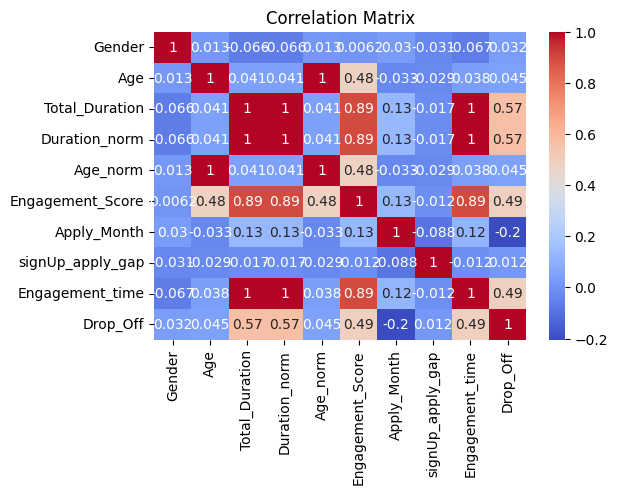

In [ ]:
# Correlation Analysis
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Inspection of Status_Description
df['Status_Description'].value_counts()

,count
Status_Description,
Rejected,3503
Team Allocated,3231
Started,758
Dropped Out,612
Waitlisted,105
Applied,104
Withdraw,84
Rewards Award,29


In [ ]:
# Create Target Variable
successful = ['Rewards award', 'Team allocated', 'Started']
dropoff = ['Drop out', 'Withdraw', 'Rejected']

# Keep only final outcome records
df = df[df['Status_Description'].isin(successful + dropoff)]

# Create binary target
df['Drop_Off'] = df['Status_Description'].apply(
    lambda x: 1 if x in dropoff else 0
)

df['Drop_Off'].value_counts()

/tmp/ipython-input-163/1164735841.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Drop_Off'] = df['Status_Description'].apply(


,count
Drop_Off,
1,3587
0,758


In [ ]:
# Remove Target Leakage
df.drop(['Status_Description'], axis=1, inplace=True)

/tmp/ipython-input-163/1240565397.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['Status_Description'], axis=1, inplace=True)


In [ ]:
if 'Status_Code' in df.columns:
    df.drop(['Status_Code'], axis=1, inplace=True)

/tmp/ipython-input-163/3764980372.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['Status_Code'], axis=1, inplace=True)


Feature Engineering

In [ ]:
# Date Coversion
if 'Opportunity Start Date' in df.columns and 'Opportunity End Date' in df.columns:
    df['Opportunity Start Date'] = pd.to_datetime(df['Opportunity Start Date'])
    df['Opportunity End Date'] = pd.to_datetime(df['Opportunity End Date'])
    df['Duration_days'] = (df['Opportunity End Date'] - df['Opportunity Start Date']).dt.days
    df.drop(['Opportunity Start Date', 'Opportunity End Date'], axis=1, inplace=True)

In [ ]:
# Create Age Groups
bins = [0,25,35,45,100]
labels = ['18-25','26-35','36-45','46+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [ ]:
# Define Features and Target
X = df.drop('Drop_Off', axis=1)
y = df['Drop_Off']

In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

categorical_cols = X.select_dtypes(include=['object','category']).columns
numeric_cols = X.select_dtypes(include=['int64','float64']).columns

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # Fix missing numeric values
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fix missing categorical values
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)


In [ ]:
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.9923312883435583
ROC-AUC: 0.997447633539077
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       227
           1       1.00      0.99      1.00      1077

    accuracy                           0.99      1304
   macro avg       0.98      1.00      0.99      1304
weighted avg       0.99      0.99      0.99      1304



In [ ]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9923312883435583
ROC-AUC: 0.9964475476421287
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       227
           1       1.00      0.99      1.00      1077

    accuracy                           0.99      1304
   macro avg       0.98      1.00      0.99      1304
weighted avg       0.99      0.99      0.99      1304



In [ ]:
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting
Accuracy: 0.9930981595092024
ROC-AUC: 0.9960651017060771
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       227
           1       1.00      0.99      1.00      1077

    accuracy                           0.99      1304
   macro avg       0.98      1.00      0.99      1304
weighted avg       0.99      0.99      0.99      1304



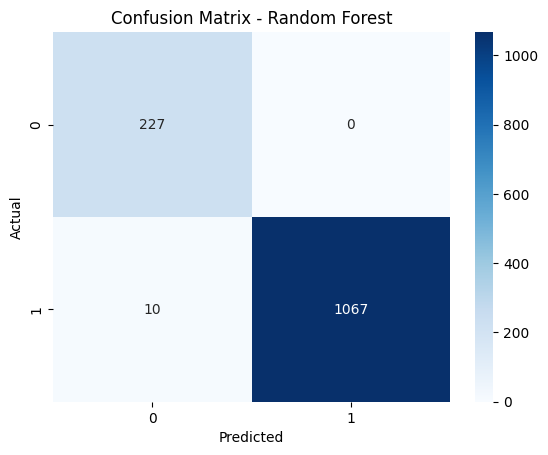

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

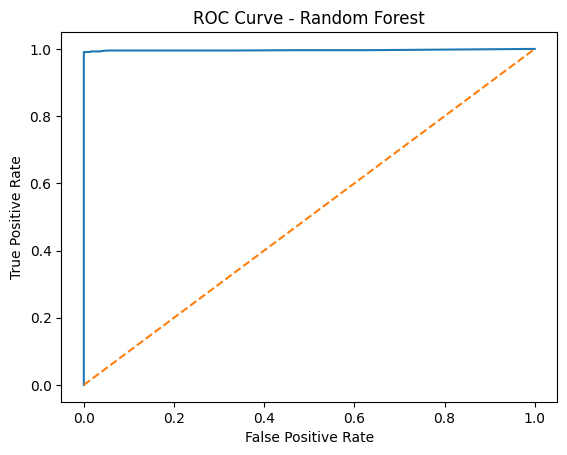

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

In [ ]:
from google.colab import files
files.download('feature Engineering.xlsx')

FileNotFoundError: Cannot find file: feature Engineering.xlsx